In [25]:
import pandas as pd
import requests
from ckanapi import RemoteCKAN
from io import BytesIO
from matplotlib import pyplot as plt

In [15]:
def get_pogoh_trip_data(portal, months_back=6):

    #Get metadata for the POGOH trip dataset
    package = portal.action.package_show(id='pogoh-trip-data')
    resources = package['resources']
    
    #Sort resources created date
    resources = sorted(resources, key=lambda x: x.get('created', ''), reverse=True)
    
    all_data = []
    count = 0
    
    for res in resources:
        if count >= months_back:
            break
            
        print(f"Downloading: {res['name']}")
        
        #Download the file into memory
        response = requests.get(res['url'])
        if response.status_code == 200:
            # POGOH typically uses Excel (.xlsx)
            try:
                # Use BytesIO to read the content without saving to disk
                df = pd.read_excel(BytesIO(response.content))
                all_data.append(df)
                count += 1
            except Exception as e:
                print(f" Could not read {res['name']}: {e}")
        else:
            print(f" Failed to download {res['name']}")

    # Combine all months into one big DataFrame
    if len(all_data) > 0:
        final_df = pd.concat(all_data, ignore_index=True)
        print(f"\nSuccess! Merged {count} months. Total rows: {len(final_df)}")
        return final_df
    else:
        print("No data found.")
        return None



In [ ]:
#Connect to WPRDC
wprdc = RemoteCKAN('https://data.wprdc.org')
# Execute
df = get_pogoh_trip_data(wprdc, 12)

if df is not None:
    print(df.dtypes)

Downloading: POGOH Trip Data - January 2026
Downloading:  POGOH Trip Data - December 2025
Downloading: POGOH Trip Data - November 2025
Downloading: POGOH Trip Data - October 2025
Downloading: POGOH Trip Data - September 2025
Downloading: POGOH Trip Data - August 2025
Downloading: POGOH Trip Data - July 2025
Downloading: POGOH Trip Data - June 2025
Downloading: POGOH Trip Data - May 2025
Downloading: POGOH Trip Data - March 2025
Downloading: POGOH Trip Data - April 2025
Downloading: POGOH Trip Data - February 2025

Success! Merged 12 months. Total rows: 572716
  Closed Status  Duration  Start Station Id          Start Date  \
0        NORMAL       666                50 2026-01-31 23:07:55   
1        NORMAL       860                13 2026-01-31 21:46:51   
2        NORMAL       312                38 2026-01-31 21:38:35   
3        NORMAL       323                59 2026-01-31 21:13:44   
4        NORMAL       351                10 2026-01-31 20:59:52   

                    Start Stati

In [29]:
#Filter out non-normal rides
print(df.shape)
df = df[df['Closed Status'] == 'NORMAL'] 
print(df.shape)
#Collapse to Daily Data
df_daily = df.resample('D', on='Start Date').count()
print(df_daily.shape)

(572716, 9)
(548710, 9)
(365, 8)


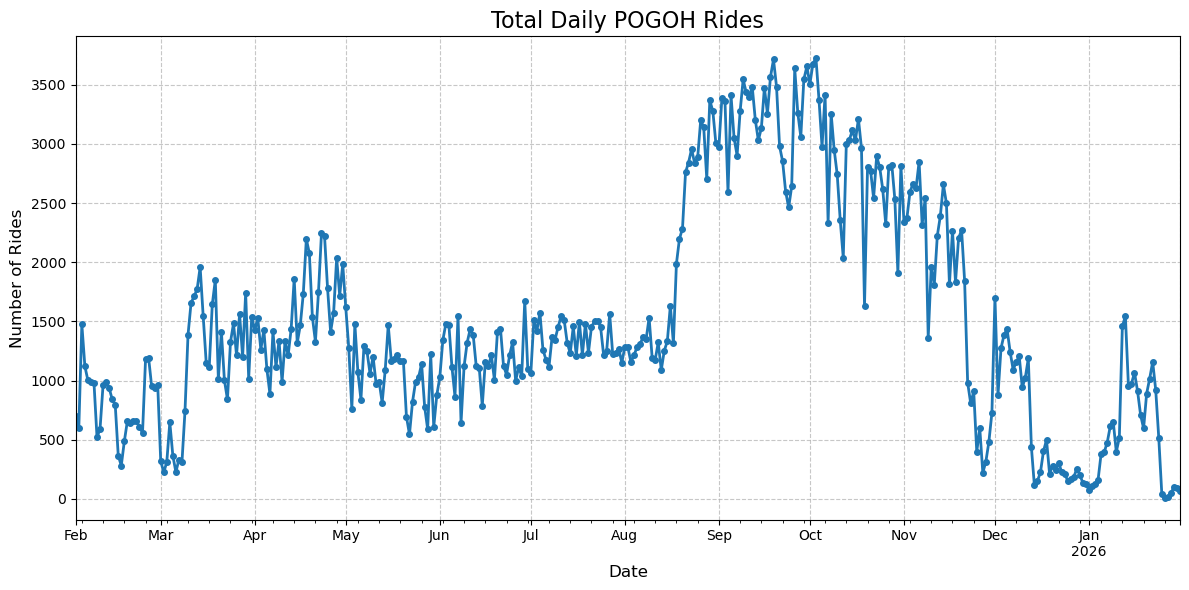

In [30]:
#Plot Time Series
plt.figure(figsize=(12, 6))
df_daily['Rider Type'].plot(kind='line', color='#1f77b4', linewidth=2, marker='o', markersize=4)

plt.title('Total Daily POGOH Rides', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()